In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/competitions/playground-series-s6e3/sample_submission.csv
/kaggle/input/competitions/playground-series-s6e3/train.csv
/kaggle/input/competitions/playground-series-s6e3/test.csv


# Load Data

In [2]:
train=pd.read_csv("/kaggle/input/competitions/playground-series-s6e3/train.csv")
test=pd.read_csv("/kaggle/input/competitions/playground-series-s6e3/test.csv")
sub=pd.read_csv("/kaggle/input/competitions/playground-series-s6e3/sample_submission.csv")

# Show Data

In [3]:
train.head(10)

,id,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,Male,0,Yes,Yes,29,Yes,No,DSL,Yes,...,Yes,Yes,No,No,One year,Yes,Mailed check,60.10,1653.85,No
1,1,Male,0,Yes,Yes,58,Yes,No,DSL,Yes,...,No,Yes,Yes,No,Two year,No,Credit card (automatic),69.50,3778.20,No
2,2,Male,0,Yes,No,58,Yes,Yes,Fiber optic,No,...,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,100.40,5841.35,No
3,3,Female,0,No,No,1,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,69.70,70.70,Yes
4,4,Female,0,No,No,1,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.45,70.45,Yes
5,5,Male,0,Yes,Yes,1,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Month-to-month,Yes,Bank transfer (automatic),20.20,20.20,No
6,6,Female,0,Yes,Yes,24,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Mailed check,20.40,533.60,No
7,7,Male,0,Yes,No,72,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,Two year,No,Electronic check,92.00,6827.50,No
8,8,Female,1,No,No,1,Yes,Yes,Fiber optic,No,...,Yes,No,No,No,Month-to-month,Yes,Electronic check,79.55,79.55,Yes
9,9,Male,0,No,No,55,Yes,No,Fiber optic,Yes,...,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,100.05,4738.30,No


# Quick Info

In [4]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 594194 entries, 0 to 594193
Data columns (total 21 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   id                594194 non-null  int64  
 1   gender            594194 non-null  object 
 2   SeniorCitizen     594194 non-null  int64  
 3   Partner           594194 non-null  object 
 4   Dependents        594194 non-null  object 
 5   tenure            594194 non-null  int64  
 6   PhoneService      594194 non-null  object 
 7   MultipleLines     594194 non-null  object 
 8   InternetService   594194 non-null  object 
 9   OnlineSecurity    594194 non-null  object 
 10  OnlineBackup      594194 non-null  object 
 11  DeviceProtection  594194 non-null  object 
 12  TechSupport       594194 non-null  object 
 13  StreamingTV       594194 non-null  object 
 14  StreamingMovies   594194 non-null  object 
 15  Contract          594194 non-null  object 
 16  PaperlessBilling  59

# Count unique values in every column

In [5]:
train.nunique()

id                  594194
gender                   2
SeniorCitizen            2
Partner                  2
Dependents               2
tenure                  72
PhoneService             2
MultipleLines            3
InternetService          3
OnlineSecurity           3
OnlineBackup             3
DeviceProtection         3
TechSupport              3
StreamingTV              3
StreamingMovies          3
Contract                 3
PaperlessBilling         2
PaymentMethod            4
MonthlyCharges        1921
TotalCharges         31910
Churn                    2
dtype: int64

# See Data value are how distributed

In [6]:
train.describe()

,id,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,594194.000000,594194.000000,594194.000000,594194.000000,594194.000000
mean,297096.500000,0.114102,36.577258,65.866223,2494.377057
std,171529.177262,0.317936,25.061922,31.067444,2353.916710
min,0.000000,0.000000,1.000000,18.250000,18.800000
25%,148548.250000,0.000000,12.000000,29.900000,639.650000
50%,297096.500000,0.000000,35.000000,74.100000,1433.650000
75%,445644.750000,0.000000,62.000000,90.800000,4263.800000
max,594193.000000,1.000000,72.000000,118.750000,8684.800000


# See Yes and NO Ratio Is ok!

In [7]:
train["Churn"].value_counts()

Churn
No     460377
Yes    133817
Name: count, dtype: int64

# Drop ID and Store Test IDs

In [8]:
train = train.drop("id", axis=1)
test_ids = test["id"]
test = test.drop("id", axis=1)

# Encode Target

In [9]:
train["Churn"] = train["Churn"].map({"No":0, "Yes":1})

# Correlation Heatmap

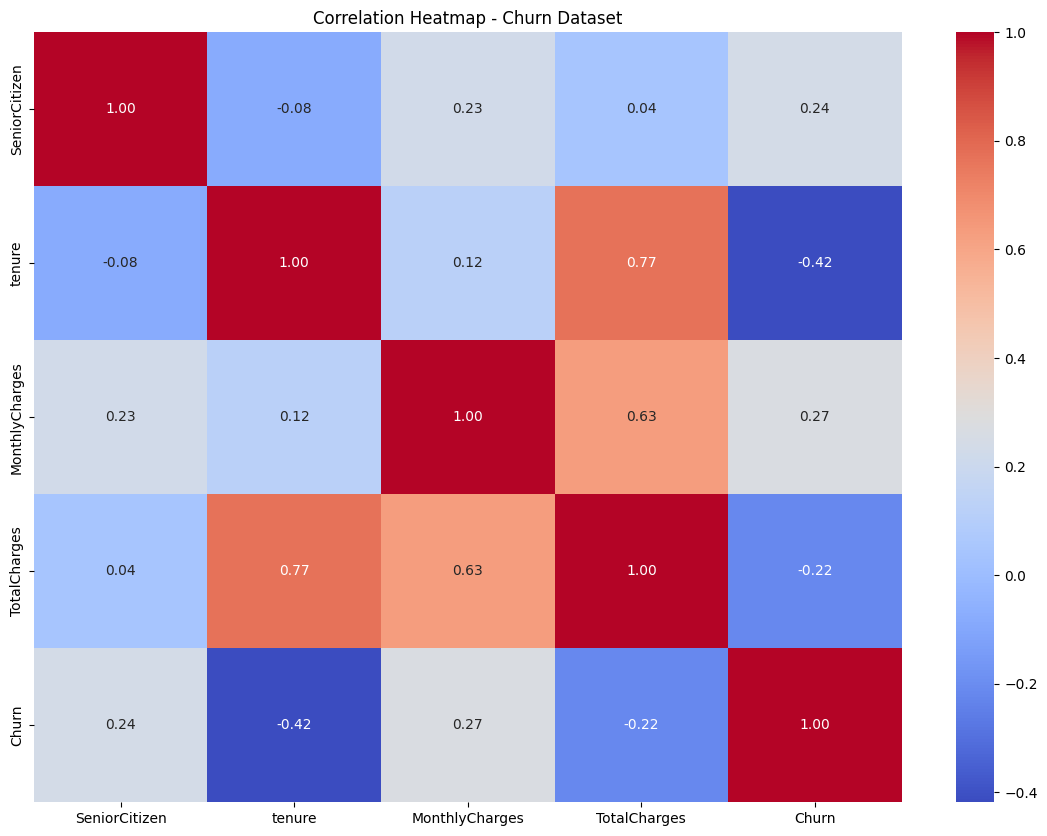

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select numeric columns only
corr = train.corr(numeric_only=True)

plt.figure(figsize=(14,10))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap - Churn Dataset")
plt.show()

# Count Churn basis of Contract

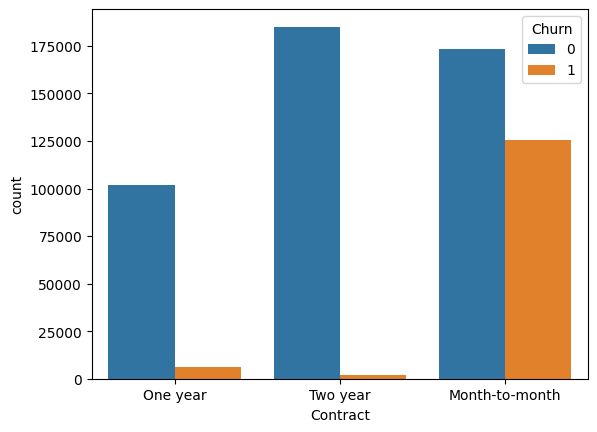

In [11]:
sns.countplot(data=train, x="Contract", hue="Churn")
plt.show()

# Smart Feature Engineering
Churn is mostly influenced by:

tenure

contract

monthly charges

internet service

payment method

In [12]:
# Customer Lifetime Value approx
train["CLV"] = train["tenure"] * train["MonthlyCharges"]
test["CLV"] = test["tenure"] * test["MonthlyCharges"]

# Average monthly spend
train["AvgCharge"] = train["TotalCharges"] / (train["tenure"] + 1)
test["AvgCharge"] = test["TotalCharges"] / (test["tenure"] + 1)

# High value customer flag
train["HighValue"] = (train["MonthlyCharges"] > 80).astype(int)
test["HighValue"] = (test["MonthlyCharges"] > 80).astype(int)

# Mark Categorical Columns
XGBoost handles categorical properly.

In [13]:
cat_cols = [
    "gender","Partner","Dependents","PhoneService",
    "MultipleLines","InternetService","OnlineSecurity",
    "OnlineBackup","DeviceProtection","TechSupport",
    "StreamingTV","StreamingMovies","Contract",
    "PaperlessBilling","PaymentMethod"
]

for col in cat_cols:
    train[col] = train[col].astype("category")
    test[col] = test[col].astype("category")

# Target Split

In [14]:
X = train.drop("Churn", axis=1)
y = train["Churn"]

# XGBoost Parameters (Optimized for Tabular)

In [15]:
from xgboost import XGBClassifier

xgb_params = {
    "objective": "binary:logistic",
    "eval_metric": "auc",
    "n_estimators": 3000,
    "learning_rate": 0.02,
    "max_depth": 5,
    "min_child_weight": 3,
    "subsample": 0.85,
    "colsample_bytree": 0.85,
    "gamma": 0.2,
    "reg_lambda": 5,
    "reg_alpha": 1,
    "enable_categorical": True,
    "tree_method": "hist",
    "random_state": 42
}

# Stratified KFold CV
Cross-Validation with AUC

In [16]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score
import numpy as np

kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

aucs = []

for fold, (train_idx, val_idx) in enumerate(kf.split(X, y), 1):
    
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

    model = XGBClassifier(**xgb_params)

    model.fit(
        X_train,
        y_train,
        eval_set=[(X_val, y_val)],
        verbose=False
    )

    preds = model.predict_proba(X_val)[:,1]
    auc = roc_auc_score(y_val, preds)

    aucs.append(auc)
    print(f"Fold {fold} AUC: {auc:.5f}")

print("Mean AUC:", np.mean(aucs))

Fold 1 AUC: 0.91641
Fold 2 AUC: 0.91737
Fold 3 AUC: 0.91693
Fold 4 AUC: 0.91789
Fold 5 AUC: 0.91506
Mean AUC: 0.9167318020274846


# Training Final Model on All Data

In [17]:
final_model = XGBClassifier(**xgb_params)
final_model.fit(X, y)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.85, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='auc', feature_types=None,
              feature_weights=None, gamma=0.2, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.02, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
              max_leaves=None, min_child_weight=3, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=3000,
              n_jobs=None, num_parallel_tree=None, ...)

# Predict Probabilities

In [18]:
preds = final_model.predict_proba(test)[:, 1]

In [19]:
sub.head()

,id,Churn
0,594194,0
1,594195,0
2,594196,0
3,594197,0
4,594198,0


# Create Submission File

In [20]:
submission = pd.DataFrame({
    "id": test_ids,
    "Churn": preds
})

submission.to_csv("submission.csv", index=False)

# Check File

In [21]:
pd.read_csv("submission.csv").head()

,id,Churn
0,594194,0.078383
1,594195,0.000398
2,594196,0.106069
3,594197,0.003453
4,594198,0.508980
